In [36]:
import torch
import numpy as np
import gymnasium
import pathlib
import cma
import multiprocessing
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)
import random

class config:
  Z_DIM:int=32
  RNN_HIDDEN:int=256
  N_MIXTURE:int=5
  IMG:int=64
  ACTION_DIM:int=3
  KL_TOLERANCE:float=0.5
  SEQ_LEN:int=100

import torch.nn as nn
import torch.nn.functional as F
import os
pathlib.Path("data").mkdir(exist_ok=True)
pathlib.Path("ckpt").mkdir(exist_ok=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

cuda


In [2]:
!pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 10.1 MB/s eta 0:00:00


In [4]:
class CarRacingEnv:
  def __init__(self, seed=None):
    self.env=gymnasium.make("CarRacing-v3", continuous=True)
    self.seed=seed
  def reset(self):
    obs, info=self.env.reset(seed=self.seed)
    for _ in range(50):
      obs, _, _, _, _ = self.env.step(np.array([0.0, 0.0, 0.0], dtype=np.float32))
    return self.preprocess(obs)
  def step(self, action):
    obs, reward, terminated, truncated, info=self.env.step(action)
    done=terminated or truncated
    return self.preprocess(obs), reward, done, info
  def close(self):
    self.env.close()
  @staticmethod
  def preprocess(image):
    image_new=torch.from_numpy(image).permute(2,0,1).unsqueeze(0).float()/255.0

    image_new=F.interpolate(
        image_new,
        size=(64, 64),
        mode="bilinear",
        align_corners=False,

    )
    return image_new.squeeze(0)

In [11]:
for i in range(200):
  racing_env=CarRacingEnv(seed=i)
  racing_env.reset()
  observations=[]
  actions=[]
  current_action=None
  counter=0
  for j in range(1000):
    if counter==0:
      steer=np.random.uniform(-1.0,1.0)
      gas=np.random.uniform(0.3,1.0)
      brake=0.0
      action = np.array([steer, gas, brake], dtype=np.float32)
      #sample new action
      counter=10
    counter-=1
    obs, rewards, done, info=racing_env.step(action)
    observations.append((obs.numpy() * 255).astype(np.uint8))
    actions.append(action)
    if done:
      break

  obs_arr = np.stack(observations)            # (T, 3, 64, 64) uint8
  act_arr = np.stack(actions).astype(np.float32)  # (T, 3)
  np.savez_compressed(f"data/rollout_{i}.npz", obs=obs_arr, actions=act_arr)
  racing_env.close()

In [6]:
!pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.0 MB/s eta 0:00:00


In [10]:
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.9 MB/s eta 0:00:00


(950, 3, 64, 64) uint8
(950, 3) float32


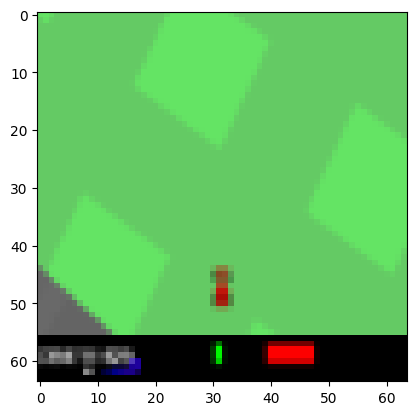

In [12]:
d = np.load("data/rollout_0.npz")
print(d["obs"].shape, d["obs"].dtype)      # expect (T, 3, 64, 64) uint8
print(d["actions"].shape, d["actions"].dtype)  # expect (T, 3) float32

import matplotlib.pyplot as plt
frame = d["obs"][100].transpose(1, 2, 0)   # (3,64,64) → (64,64,3) for imshow
plt.imshow(frame); plt.show()

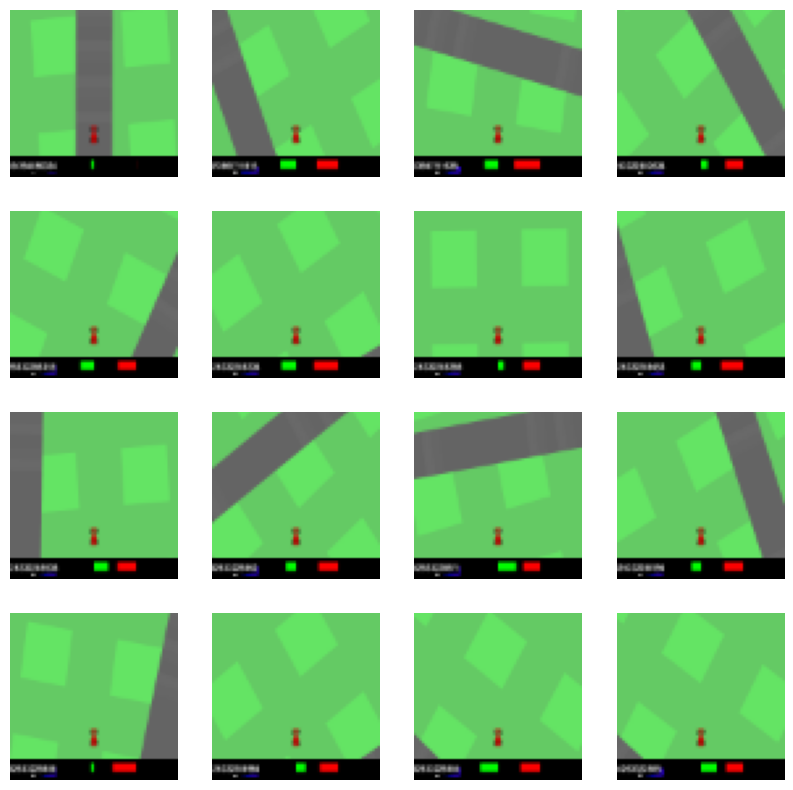

In [13]:
d = np.load("data/rollout_0.npz")
fig, ax = plt.subplots(4, 4, figsize=(10,10))
for k in range(16):
    f = d["obs"][k*60].transpose(1,2,0)   # every 60th frame across the rollout
    ax[k//4, k%4].imshow(f); ax[k//4, k%4].axis("off")
plt.show()

In [14]:
len(list(pathlib.Path("data").glob("*.npz"))) == 200

True

In [15]:
class VAE_encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(3,32,4,2)
    self.relu1=nn.ReLU()
    self.conv2=nn.Conv2d(32,64,4,2)
    self.relu2=nn.ReLU()
    self.conv3=nn.Conv2d(64,128,4,2)
    self.relu3=nn.ReLU()
    self.conv4=nn.Conv2d(128,256,4,2)
    self.relu4=nn.ReLU()

    self.linear1=nn.Linear(1024,32)
    self.linear2=nn.Linear(1024,32)
  def forward(self, x):
    x=self.relu1(self.conv1(x))
    x=self.relu2(self.conv2(x))
    x=self.relu3(self.conv3(x))
    x=self.relu4(self.conv4(x))
    x=torch.flatten(x, start_dim=1)
    mu=self.linear1(x)
    log_var=self.linear2(x)
    return mu, log_var

class VAE_decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear1=nn.Linear(config.Z_DIM, 1024)
    self.relu1=nn.ReLU()
    self.conv1=nn.ConvTranspose2d(1024,128,5,2)
    self.relu2=nn.ReLU()
    self.conv2=nn.ConvTranspose2d(128,64,5,2)
    self.relu3=nn.ReLU()
    self.conv3=nn.ConvTranspose2d(64,32,6,2)
    self.relu4=nn.ReLU()
    self.conv4=nn.ConvTranspose2d(32,3,6,2)
    self.sigmoid=nn.Sigmoid()
  def forward(self, x):
    x=self.relu1(self.linear1(x))
    x=x.view(-1,1024,1,1)
    x=self.relu2(self.conv1(x))
    x=self.relu3(self.conv2(x))
    x=self.relu4(self.conv3(x))
    x=self.sigmoid(self.conv4(x))
    return x







In [16]:
enc = VAE_encoder().to(device)
dec = VAE_decoder().to(device)
x = torch.randn(4, 3, 64, 64).to(device)
mu, logvar = enc(x)
z = mu                              # just to test decode path
recon = dec(z)
print(mu.shape, logvar.shape, recon.shape)
# expect: (4,32) (4,32) (4,3,64,64)

torch.Size([4, 32]) torch.Size([4, 32]) torch.Size([4, 3, 64, 64])


In [17]:
class ConvVAE(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder=VAE_encoder()
    self.decoder=VAE_decoder()
  def forward(self, x):
    mu, logvar=self.encoder(x)

    std=torch.exp(0.5*logvar)
    eps=torch.randn_like(mu)

    z=mu+std*eps

    reconstruction=self.decoder(z)
    return reconstruction, mu, logvar

In [37]:
import glob
from torch.utils.data import Dataset, DataLoader

class FrameDataset(Dataset):
  def __init__(self, data_directory='/content/data/*.npz'):
    list_of_files=[]
    data=glob.glob(data_directory)
    for datapoint in data:
      d=np.load(datapoint)
      list_of_files.append(d["obs"])
    self.frames=np.concatenate(list_of_files, axis=0)
  def __len__(self):
    return len(self.frames)
  def __getitem__(self, idx):
    frame=self.frames[idx]
    return torch.from_numpy(frame).float()/255.0





In [19]:
dataset = Dataset()
print(len(dataset), dataset[0].shape, dataset[0].dtype, dataset[0].max())
# expect ~190000, (3,64,64), float32, ~1.0

189284 torch.Size([3, 64, 64]) torch.float32 tensor(0.8941)


In [20]:
loader=DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
vae=ConvVAE().to(device)
opt=torch.optim.Adam(vae.parameters(), lr=1e-4)


In [21]:
for epoch in range(10):
    recon_sum, kl_sum, n = 0.0, 0.0, 0
    for b, batch in enumerate(loader):
        x = batch.to(device)
        recon, mu, logvar = vae(x)

        recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
        kl = -0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar), dim=1)
        kl = torch.clamp(kl, min=config.KL_TOLERANCE * config.Z_DIM)
        kl_loss = kl.mean()
        loss = recon_loss + kl_loss

        opt.zero_grad(); loss.backward(); opt.step()

        recon_sum += recon_loss.item(); kl_sum += kl_loss.item(); n += 1
        if b % 500 == 0:
            print(f"epoch {epoch} batch {b}  recon {recon_loss.item():.1f}  kl {kl_loss.item():.2f}")

    print(f"== epoch {epoch}: recon {recon_sum/n:.1f}  kl {kl_sum/n:.2f}")
    torch.save(vae.state_dict(), "ckpt/vae.pt")

epoch 0 batch 0  recon 762.0  kl 16.00
epoch 0 batch 500  recon 80.7  kl 16.21
epoch 0 batch 1000  recon 51.1  kl 16.67
epoch 0 batch 1500  recon 44.8  kl 16.46
epoch 0 batch 2000  recon 34.1  kl 16.42
epoch 0 batch 2500  recon 32.0  kl 16.66
== epoch 0: recon 66.6  kl 16.56
epoch 1 batch 0  recon 31.3  kl 16.24
epoch 1 batch 500  recon 29.5  kl 16.38
epoch 1 batch 1000  recon 28.3  kl 16.61
epoch 1 batch 1500  recon 25.2  kl 16.79
epoch 1 batch 2000  recon 20.9  kl 16.60
epoch 1 batch 2500  recon 21.1  kl 17.04
== epoch 1: recon 24.8  kl 16.60
epoch 2 batch 0  recon 21.7  kl 16.83
epoch 2 batch 500  recon 22.3  kl 16.94
epoch 2 batch 1000  recon 19.7  kl 16.62
epoch 2 batch 1500  recon 18.3  kl 16.49
epoch 2 batch 2000  recon 19.3  kl 16.59
epoch 2 batch 2500  recon 19.5  kl 16.84
== epoch 2: recon 19.4  kl 16.67
epoch 3 batch 0  recon 18.0  kl 16.61
epoch 3 batch 500  recon 17.5  kl 16.81
epoch 3 batch 1000  recon 18.2  kl 16.87
epoch 3 batch 1500  recon 18.3  kl 16.76
epoch 3 batch 

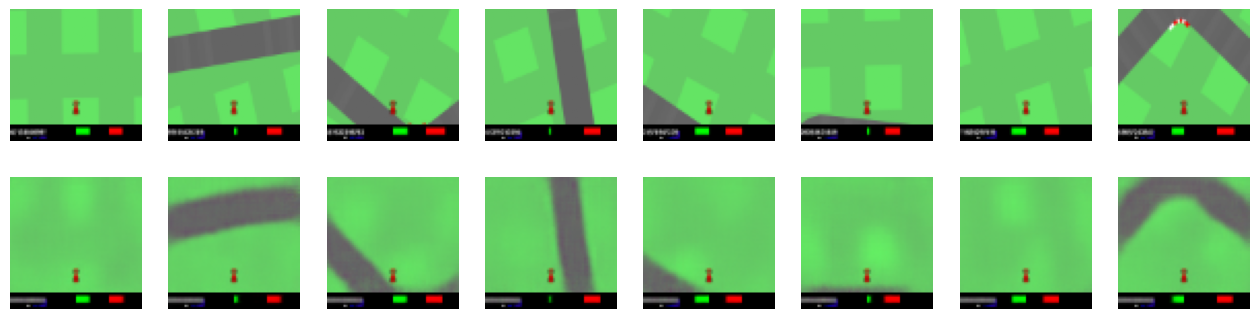

In [25]:
vae.eval()
with torch.no_grad():
    x = next(iter(loader))[:8].to(device)   # 8 frames
    recon, mu, logvar = vae(x)

x = x.cpu(); recon = recon.cpu()
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    ax[0, i].imshow(x[i].permute(1, 2, 0)); ax[0, i].axis("off")       # top row: originals
    ax[1, i].imshow(recon[i].permute(1, 2, 0)); ax[1, i].axis("off")  # bottom row: reconstructions
ax[0, 0].set_ylabel("orig"); ax[1, 0].set_ylabel("recon")
plt.show()

In [26]:
vae.eval()
with torch.no_grad():
    data = glob.glob("/content/data/rollout_*.npz")
    for idx, path in enumerate(data):
        d = np.load(path)
        obs = d["obs"]
        action = d["actions"]
        frame = torch.from_numpy(obs).float() / 255.0

        mus, logvars = [], []
        for k in range(0, frame.shape[0], 256):
            chunk = frame[k:k+256].to(device)
            mu, logvar = vae.encoder(chunk)
            mus.append(mu.cpu()); logvars.append(logvar.cpu())
        mu_seq = torch.cat(mus).numpy()
        logvar_seq = torch.cat(logvars).numpy()

        np.savez_compressed(f"data/latent_{idx}.npz",
                            mu=mu_seq, logvar=logvar_seq, actions=action)
        if idx % 20 == 0:
            print(f"encoded rollout {idx}")

encoded rollout 0
encoded rollout 20
encoded rollout 40
encoded rollout 60
encoded rollout 80
encoded rollout 100
encoded rollout 120
encoded rollout 140
encoded rollout 160
encoded rollout 180


In [27]:
d = np.load("data/latent_0.npz")
print(d["mu"].shape, d["logvar"].shape, d["actions"].shape)   # (T,32) (T,32) (T,3)
print(d["mu"].min(), d["mu"].max())   # roughly within [-3, 3]

(950, 32) (950, 32) (950, 3)
-2.3120456 3.2258046


In [31]:
class LSTMCell(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.hidden_size=hidden_size
    self.weight=nn.Linear(input_size+hidden_size, 4*hidden_size)
  def forward(self, x, state):
    h_prev, c_prev = state
    combined = torch.cat([x, h_prev], dim=-1)          # (B, input+hidden)
    gates = self.weight(combined)                       # (B, 4*hidden)
    f, i, g, o = gates.chunk(4, dim=-1)                 # each (B, hidden)
    f = torch.sigmoid(f)
    i = torch.sigmoid(i)
    g = torch.tanh(g)
    o = torch.sigmoid(o)
    c = f * c_prev + i * g
    h = o * torch.tanh(c)
    return h, c
class MDN(nn.Module):
  def __init__(self):
    super().__init__()
    self.cell=LSTMCell(config.Z_DIM+config.ACTION_DIM, config.RNN_HIDDEN)
    self.mdn=nn.Linear(config.RNN_HIDDEN, config.N_MIXTURE*config.Z_DIM*3)
  def forward(self, z, a, state=None):
    x=torch.cat([z, a], dim=-1)

    B, T, _=x.shape

    if state is None:
      h=torch.zeros(B, config.RNN_HIDDEN, device=x.device)
      c=torch.zeros(B, config.RNN_HIDDEN, device=x.device)
    else:
      h, c=state
    outputs=[]
    for t in range(T):
      h, c=self.cell(x[:, t, :],(h, c))
      outputs.append(h)
    lstm_out=torch.stack(outputs, dim=1)
    out=self.mdn(lstm_out)
    out=out.view(B, T, config.Z_DIM, config.N_MIXTURE, 3)

    pi=out[..., 0]
    mu=out[..., 1]
    logsigma=out[..., 2]

    return pi, mu, logsigma, (h,c)





In [32]:
m = MDN().to(device)
z = torch.randn(4, 10, 32).to(device)
a = torch.randn(4, 10, 3).to(device)
pi, mu, logsigma, (h, c) = m(z, a)
print(pi.shape, mu.shape, logsigma.shape, h.shape)
# (4,10,32,5) (4,10,32,5) (4,10,32,5) (4,256)

torch.Size([4, 10, 32, 5]) torch.Size([4, 10, 32, 5]) torch.Size([4, 10, 32, 5]) torch.Size([4, 256])


In [33]:
#losses
import math
def mdn_loss(pi, mu, logsigma, target):

  log_pi=F.log_softmax(pi, dim=-1)
  logsigma=torch.clamp(logsigma, min=-7,max=7)
  sigma=torch.exp(logsigma)
  z_exp = target.unsqueeze(-1)
  log_normal = -0.5*((z_exp - mu)/sigma)**2 - logsigma - 0.5*math.log(2*math.pi)
  log_prob = torch.logsumexp(log_pi + log_normal, dim=-1)
  loss = -log_prob.sum(dim=-1).mean()
  return loss



In [34]:
target = torch.randn(4, 10, 32).to(device)
print(mdn_loss(pi, mu, logsigma, target))   # finite positive scalar, no nan

tensor(45.6257, device='cuda:0', grad_fn=<NegBackward0>)


In [42]:
class Sequence_Dataset(Dataset):
  def __init__(self, data_directory='/content/data/latent_*.npz'):
    data=glob.glob(data_directory)
    self.chunks=[]
    L = config.SEQ_LEN + 1
    for path in glob.glob(data_directory):
      d = np.load(path)
      mu, logvar, actions = d["mu"], d["logvar"], d["actions"]
      T = mu.shape[0]
      n_chunks = T // L
      for k in range(n_chunks):
        s = slice(k*L, (k+1)*L)
        self.chunks.append((mu[s], logvar[s], actions[s]))
  def __len__(self):
    return len(self.chunks)
  def __getitem__(self, idx):
    mu, logvar, actions = self.chunks[idx]
    mu = torch.from_numpy(mu).float()
    logvar = torch.from_numpy(logvar).float()
    actions = torch.from_numpy(actions).float()
    z = mu + torch.exp(0.5*logvar) * torch.randn_like(mu)
    return z, actions







In [43]:
ds = Sequence_Dataset()
print(len(ds))                    # total chunks, e.g. ~1700 (200 rollouts × ~9 each)
z, a = ds[0]
print(z.shape, a.shape)           # (101, 32) (101, 3)

1793
torch.Size([101, 32]) torch.Size([101, 3])


In [44]:
loader = DataLoader(ds, batch_size=32, shuffle=True)

In [48]:
mdnrnn = MDN().to(device)
opt = torch.optim.Adam(mdnrnn.parameters(), lr=1e-4)

In [49]:
for epoch in range(50):
    total, n = 0.0, 0
    for b, (z, actions) in enumerate(loader):
        z, actions = z.to(device), actions.to(device)
        z_in   = z[:, :-1, :]        # z_0 … z_{99}   (B,100,32)
        a_in   = actions[:, :-1, :]  # a_0 … a_{99}   (B,100,3)
        target = z[:, 1:, :]         # z_1 … z_{100}  (B,100,32)

        pi, mu, logsigma, _ = mdnrnn(z_in, a_in)     # state=None → zeros init, loops internally
        loss = mdn_loss(pi, mu, logsigma, target)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mdnrnn.parameters(), 1.0)   # RNN safety
        opt.step()

        total += loss.item(); n += 1
        if b % 50 == 0:
            print(f"epoch {epoch} batch {b}  nll {loss.item():.3f}")
    print(f"== epoch {epoch}: nll {total/n:.3f}")
    torch.save(mdnrnn.state_dict(), "ckpt/mdnrnn.pt")

epoch 0 batch 0  nll 45.057
epoch 0 batch 50  nll 44.462
== epoch 0: nll 44.821
epoch 1 batch 0  nll 44.475
epoch 1 batch 50  nll 43.332
== epoch 1: nll 43.974
epoch 2 batch 0  nll 42.926
epoch 2 batch 50  nll 41.933
== epoch 2: nll 42.300
epoch 3 batch 0  nll 41.667
epoch 3 batch 50  nll 40.488
== epoch 3: nll 40.815
epoch 4 batch 0  nll 39.943
epoch 4 batch 50  nll 38.579
== epoch 4: nll 39.486
epoch 5 batch 0  nll 39.556
epoch 5 batch 50  nll 38.255
== epoch 5: nll 38.502
epoch 6 batch 0  nll 37.659
epoch 6 batch 50  nll 37.325
== epoch 6: nll 37.680
epoch 7 batch 0  nll 37.603
epoch 7 batch 50  nll 36.730
== epoch 7: nll 36.921
epoch 8 batch 0  nll 36.733
epoch 8 batch 50  nll 35.903
== epoch 8: nll 36.267
epoch 9 batch 0  nll 36.236
epoch 9 batch 50  nll 35.427
== epoch 9: nll 35.749
epoch 10 batch 0  nll 35.785
epoch 10 batch 50  nll 35.005
== epoch 10: nll 35.329
epoch 11 batch 0  nll 35.018
epoch 11 batch 50  nll 34.872
== epoch 11: nll 34.945
epoch 12 batch 0  nll 34.509
epoch

In [50]:
def sample_z(pi, mu, logsigma, temperature=1.0):
  logsigma=torch.clamp(logsigma, min=-7,max=7)
  sigma=torch.exp(logsigma)
  result_softmax=F.softmax(pi/temperature, dim=-1)
  sampled=torch.distributions.Categorical(probs=result_softmax)
  chosen=sampled.sample()
  idx=chosen.unsqueeze(-1)
  chosen_mu=torch.gather(mu,    -1, idx).squeeze(-1)
  chosen_sigma=torch.gather(sigma, -1, idx).squeeze(-1)
  eps = torch.randn_like(chosen_mu)
  z_next = chosen_mu + chosen_sigma * (temperature ** 0.5) * eps
  return z_next


In [51]:
out = sample_z(pi[:, 0], mu[:, 0], logsigma[:, 0])   # take one timestep → (4,32,5)
print(out.shape, out.min().item(), out.max().item(), torch.isnan(out).any().item())
# expect (4,32), values ~[-3,3]-ish, no nan

torch.Size([1, 32]) -1.6745061874389648 0.714184582233429 False


In [52]:
a = sample_z(pi[:, 0], mu[:, 0], logsigma[:, 0])
b = sample_z(pi[:, 0], mu[:, 0], logsigma[:, 0])
print((a - b).abs().mean().item())          # should be > 0 — two draws differ

lo = sample_z(pi[:, 0], mu[:, 0], logsigma[:, 0], temperature=0.1)
hi = sample_z(pi[:, 0], mu[:, 0], logsigma[:, 0], temperature=1.5)
print(lo.std().item(), hi.std().item())     # hi should vary more across runs

1.3291587829589844
0.3368971645832062 1.127455472946167


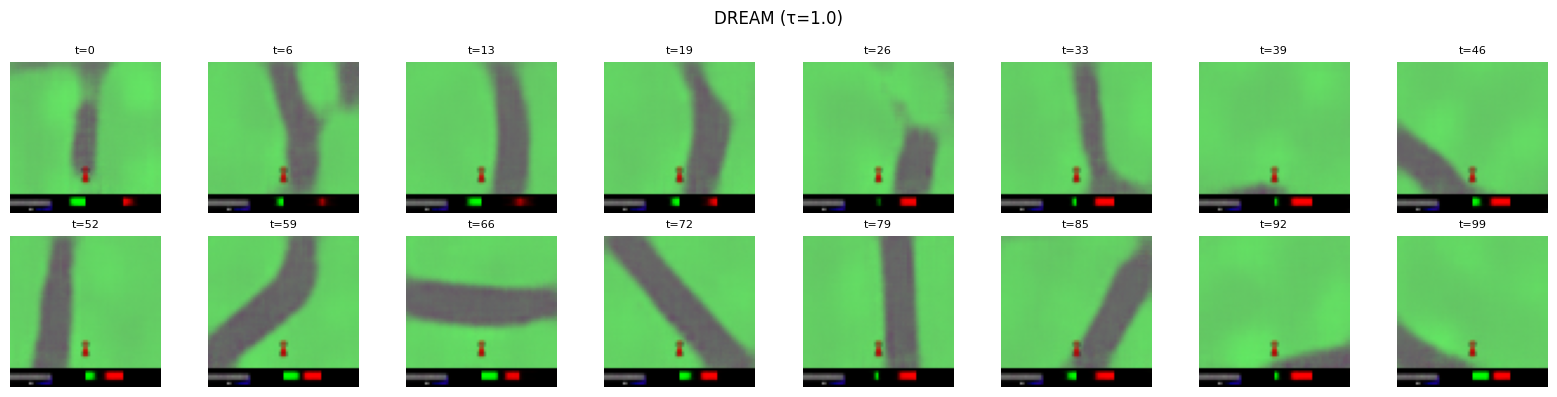

In [53]:
import matplotlib.pyplot as plt

mdnrnn.eval(); vae.eval()

# --- pick a real starting point and an action sequence to drive the dream ---
DREAM_LEN = 100
TEMPERATURE = 1.0

d = np.load("data/latent_0.npz")
z0 = torch.from_numpy(d["mu"][0]).float().to(device)          # real starting latent (32,)
actions_real = torch.from_numpy(d["actions"][:DREAM_LEN]).float().to(device)  # (DREAM_LEN,3)

# --- autoregressive dream ---
dreamed = []
with torch.no_grad():
    z = z0
    state = None
    for t in range(DREAM_LEN):
        z_in = z.view(1, 1, config.Z_DIM)                    # (1,1,32)
        a_in = actions_real[t].view(1, 1, config.ACTION_DIM) # (1,1,3)
        pi, mdn_mu, logsigma, state = mdnrnn(z_in, a_in, state)
        z_next = sample_z(pi[0, 0], mdn_mu[0, 0], logsigma[0, 0], TEMPERATURE)  # (32,)
        dreamed.append(z_next)
        z = z_next                                            # feed sample back in (the dream)

z_dream = torch.stack(dreamed, dim=0)                         # (DREAM_LEN, 32)

# --- decode dreamed latents to images ---
with torch.no_grad():
    frames_dream = vae.decoder(z_dream.to(device)).cpu()      # (DREAM_LEN, 3, 64, 64)

# --- filmstrip: 16 frames evenly spaced across the dream ---
idxs = np.linspace(0, DREAM_LEN - 1, 16).astype(int)
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i, k in enumerate(idxs):
    ax[i // 8, i % 8].imshow(frames_dream[k].permute(1, 2, 0).clamp(0, 1))
    ax[i // 8, i % 8].set_title(f"t={k}", fontsize=8)
    ax[i // 8, i % 8].axis("off")
plt.suptitle(f"DREAM (τ={TEMPERATURE})")
plt.tight_layout(); plt.show()

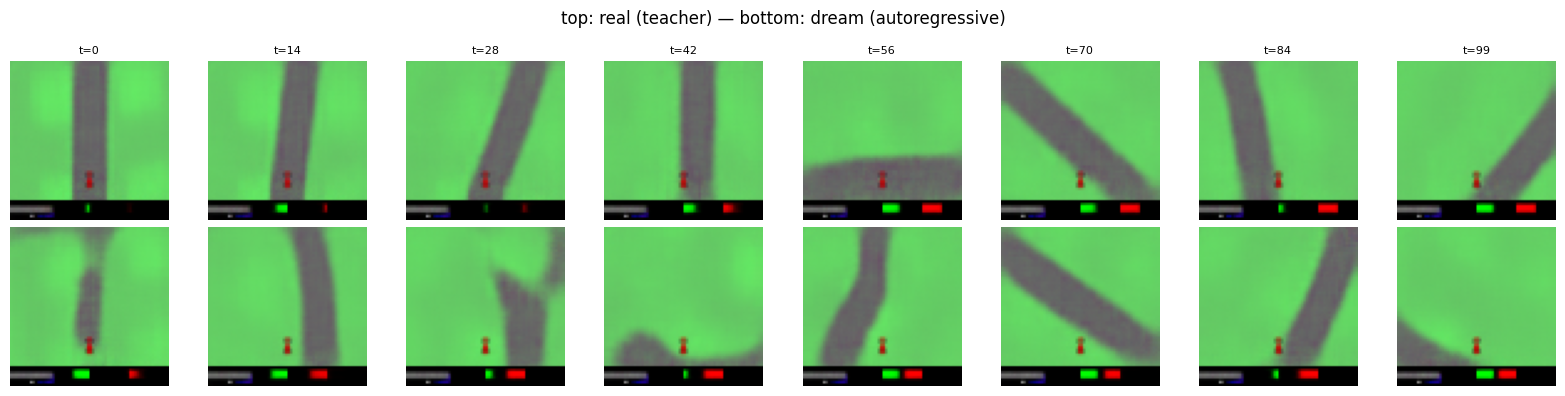

In [54]:
# real latents from the same rollout, decoded — the ground truth M is trying to match
with torch.no_grad():
    real_mu = torch.from_numpy(d["mu"][:DREAM_LEN]).float().to(device)   # (DREAM_LEN,32)
    frames_real = vae.decoder(real_mu).cpu()                             # (DREAM_LEN,3,64,64)

idxs = np.linspace(0, DREAM_LEN - 1, 8).astype(int)
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i, k in enumerate(idxs):
    ax[0, i].imshow(frames_real[k].permute(1, 2, 0).clamp(0, 1));  ax[0, i].axis("off")
    ax[1, i].imshow(frames_dream[k].permute(1, 2, 0).clamp(0, 1)); ax[1, i].axis("off")
    ax[0, i].set_title(f"t={k}", fontsize=8)
ax[0, 0].set_ylabel("REAL",  fontsize=10)
ax[1, 0].set_ylabel("DREAM", fontsize=10)
plt.suptitle("top: real (teacher) — bottom: dream (autoregressive)")
plt.tight_layout(); plt.show()

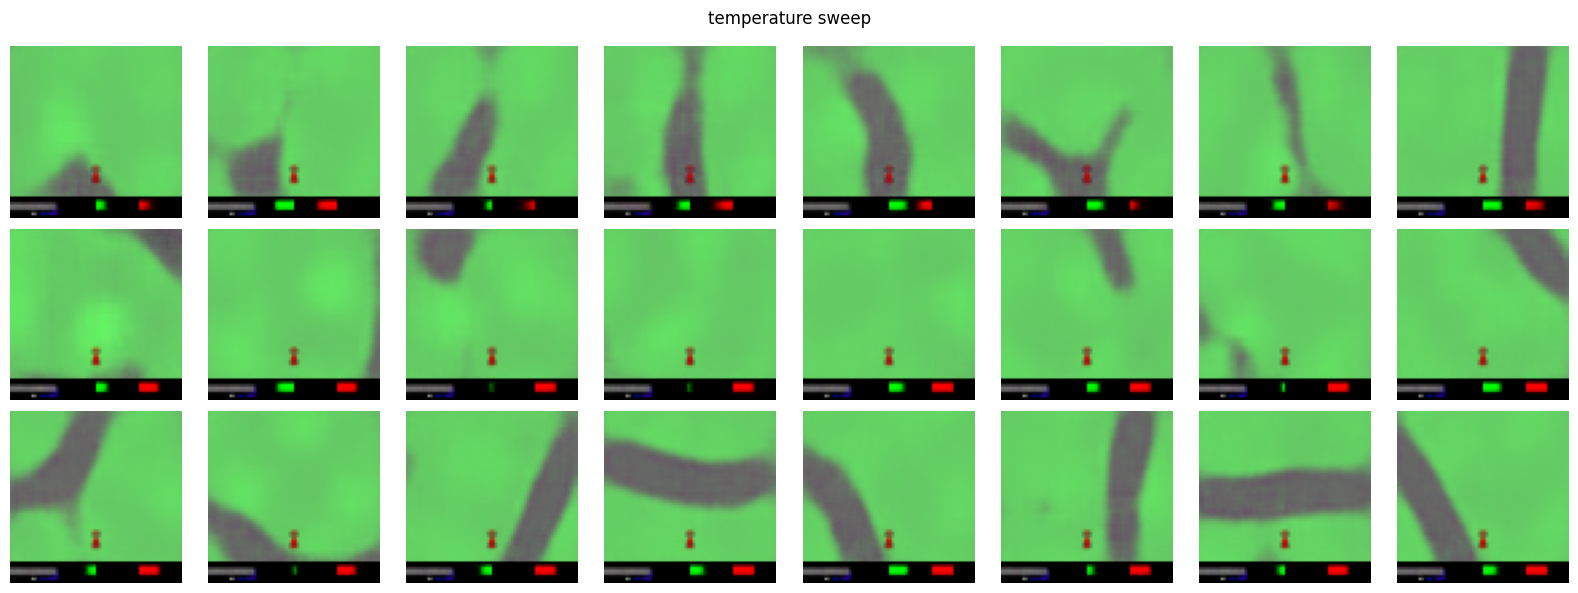

In [55]:
fig, ax = plt.subplots(3, 8, figsize=(16, 6))
for row, temp in enumerate([0.5, 1.0, 1.25]):
    dreamed = []
    with torch.no_grad():
        z = z0; state = None
        for t in range(DREAM_LEN):
            pi, mdn_mu, logsigma, state = mdnrnn(
                z.view(1,1,config.Z_DIM), actions_real[t].view(1,1,config.ACTION_DIM), state)
            z = sample_z(pi[0,0], mdn_mu[0,0], logsigma[0,0], temp)
            dreamed.append(z)
        fr = vae.decoder(torch.stack(dreamed).to(device)).cpu()
    for i, k in enumerate(np.linspace(0, DREAM_LEN-1, 8).astype(int)):
        ax[row, i].imshow(fr[k].permute(1,2,0).clamp(0,1)); ax[row, i].axis("off")
    ax[row, 0].set_ylabel(f"τ={temp}", fontsize=10)
plt.suptitle("temperature sweep"); plt.tight_layout(); plt.show()

In [56]:
!pip install -q imageio imageio-ffmpeg
import imageio

# frames_dream is (DREAM_LEN,3,64,64) float[0,1] → uint8 HWC, upscaled 4x for visibility
vid = (frames_dream.permute(0, 2, 3, 1).clamp(0, 1).numpy() * 255).astype(np.uint8)  # (N,64,64,3)
vid = np.repeat(np.repeat(vid, 4, axis=1), 4, axis=2)   # nearest-neighbor 4x → 256x256

out_path = "dream.mp4"
try:
    imageio.mimsave(out_path, vid, fps=20, codec="libx264")
except Exception as e:
    print("mp4 failed, writing gif:", e)
    out_path = "dream.gif"
    imageio.mimsave(out_path, vid, fps=20)

from google.colab import files
files.download(out_path)
print("saved + downloading:", out_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

saved + downloading: dream.mp4
